# Segmentación de clientes con K-Means

**Inteligencia Artificial I — Actividad 2 — Grupo 5**

**Notebook 2: Implementación profesional con scikit-learn**

**Integrantes:**
- Cardenas Torres Julian Camilo
- Vargas Catuche Jhon Alexander
- Vasquez Peña Juan Sebastian

**Fundación Universitaria Los Libertadores**

---

### Tabla de contenido

1. [Introducción y descripción del problema](#1-introducción-y-descripción-del-problema)
2. [Carga y exploración de datos](#2-carga-y-exploración-de-datos)
3. [Análisis exploratorio (EDA)](#3-análisis-exploratorio-de-datos-eda)
4. [Preprocesamiento](#4-preprocesamiento)
5. [Entrenamiento del modelo](#5-entrenamiento-del-modelo)
6. [Evaluación del modelo](#6-evaluación-del-modelo)
7. [Ajuste de hiperparámetros](#7-ajuste-de-hiperparámetros)
8. [Interpretación de resultados](#8-interpretación-de-resultados)
9. [Conclusiones](#9-conclusiones)
10. [Referencias](#referencias)

---
## 1. Introducción y descripción del problema

### ¿Qué problema vamos a resolver?

Una tienda departamental quiere **entender mejor a sus clientes** para diseñar campañas de marketing personalizadas. El gerente nos entregó datos de 200 clientes (edad, género, ingreso anual y puntaje de gasto) y nos pide responder:

> *¿Existen grupos naturales de clientes con comportamientos similares?*

### ¿Por qué es importante?

Identificar segmentos de clientes permite a la tienda:

-  Diseñar **promociones específicas** para cada grupo (más efectivas y baratas).
-  Optimizar el **gasto en marketing** invirtiendo en los segmentos correctos.
-  Aumentar la **fidelización** de clientes VIP y **reactivar** a los menos activos.
-  Mejorar la **experiencia de compra** según el perfil del cliente.

### Descripción del dataset

Usamos el dataset público **"Mall Customer Segmentation Data"** [1], disponible en Kaggle. Contiene 200 registros con las siguientes variables:

| Variable | Descripción | Tipo |
|---|---|---|
| `CustomerID` | Identificador único del cliente | Entero |
| `Genre` | Género (Male / Female) | Categórica |
| `Age` | Edad del cliente | Entero |
| `Annual Income (k$)` | Ingreso anual en miles de dólares | Entero |
| `Spending Score (1-100)` | Puntaje de gasto asignado por la tienda | Entero |

### ¿Por qué K-Means?

K-Means es ideal para este problema porque:
- Es un algoritmo **no supervisado** (no necesitamos etiquetas previas).
- Funciona bien con datos numéricos en escalas similares (después de estandarizar).
- Produce clusters **interpretables** (cada centroide representa un perfil).
- Es uno de los algoritmos **más usados en la industria** para segmentación de clientes.

---
## 2. Carga y exploración de datos

In [14]:
# Librerías para análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Configuración general
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 90
sns.set_style('whitegrid')
np.random.seed(42)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [15]:
# Cargar dataset Mall Customers (intenta archivo local, si no existe descarga desde URL)
df = pd.read_csv('../data/Mall_Customers_Limpio.csv')
print("Dataset cargado desde archivo local")
print(f"\nForma del dataset: {df.shape[0]} clientes, {df.shape[1]} columnas")
print("\nPrimeras 5 filas:")
df.head()

Dataset cargado desde archivo local

Forma del dataset: 200 clientes, 5 columnas

Primeras 5 filas:


,ID_Cliente,Genero,Edad,Ingreso_Anual_miles_USD,Puntuacion_Gasto_1_100
0,1,Hombre,19,15,39
1,2,Hombre,21,15,81
2,3,Mujer,20,16,6
3,4,Mujer,23,16,77
4,5,Mujer,31,17,40


In [16]:
print("INFORMACIÓN DEL DATASET")
print("="*50)
df.info()

print("\nESTADÍSTICAS DESCRIPTIVAS")
print("="*50)
df.describe()

INFORMACIÓN DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   ID_Cliente               200 non-null    int64
 1   Genero                   200 non-null    str  
 2   Edad                     200 non-null    int64
 3   Ingreso_Anual_miles_USD  200 non-null    int64
 4   Puntuacion_Gasto_1_100   200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

ESTADÍSTICAS DESCRIPTIVAS


,ID_Cliente,Edad,Ingreso_Anual_miles_USD,Puntuacion_Gasto_1_100
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


---
## 3. Análisis exploratorio de datos (EDA)

Antes de aplicar K-Means, exploramos los datos para entender:
- **Cómo se distribuyen** las variables numéricas
- **Cómo se relacionan** entre sí
- **Si hay outliers** o valores extraños

Distribuciones de las variables numéricas:


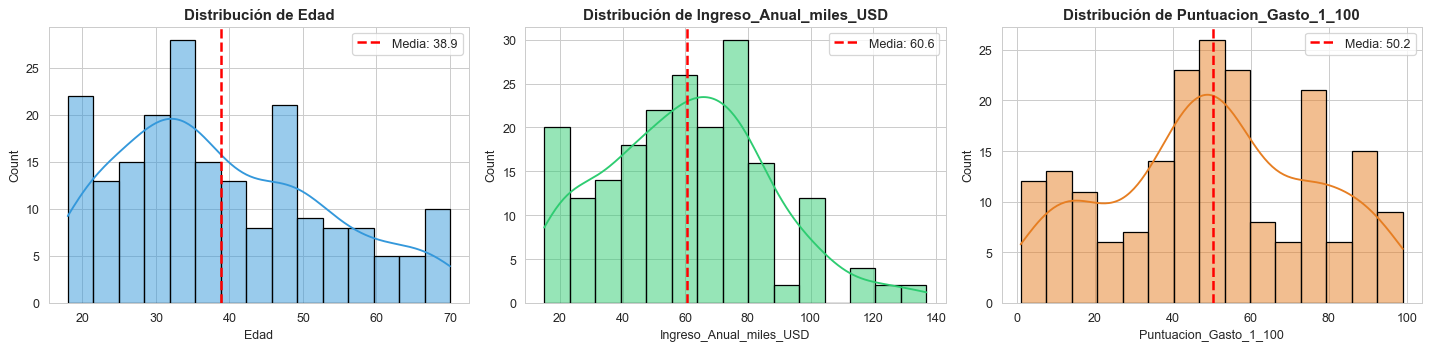


Correlaciones entre variables:


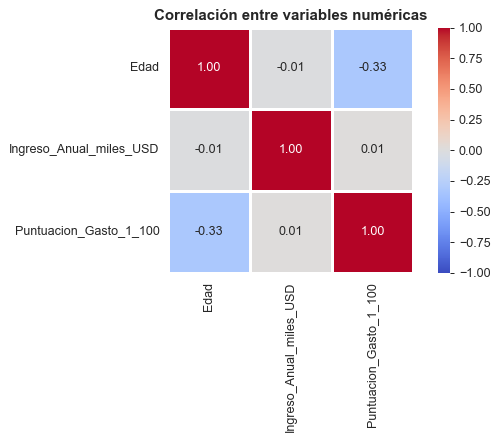


Detección de outliers:
OUTLIERS DETECTADOS (método IQR):
  • Edad: 0 outliers
  • Ingreso_Anual_miles_USD: 2 outliers
  • Puntuacion_Gasto_1_100: 0 outliers


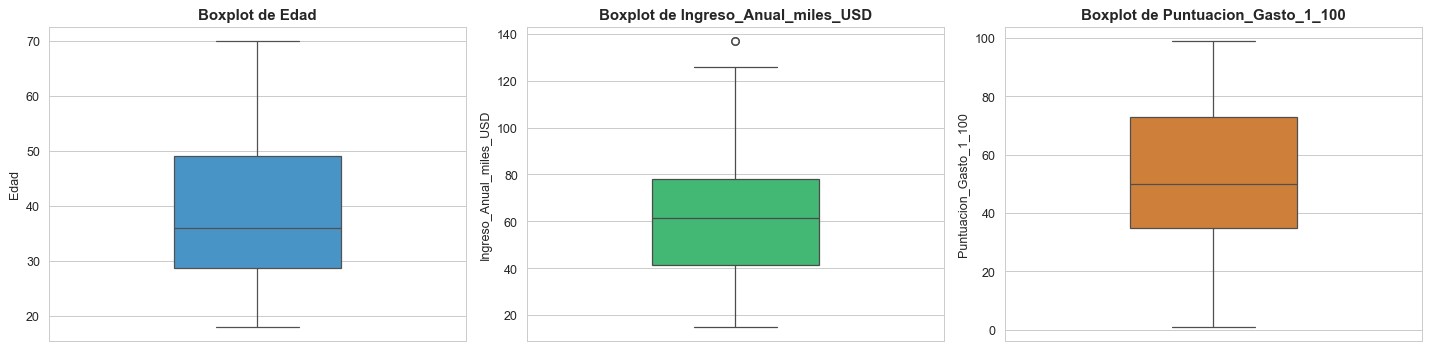

In [25]:
def graficar_distribuciones(df, columnas):
    """Genera histogramas con curva de densidad para cada variable numérica."""
    fig, axes = plt.subplots(1, len(columnas), figsize=(16, 4))
    colores = ['#3498DB', '#2ECC71', '#E67E22']
    for i, col in enumerate(columnas):
        sns.histplot(df[col], kde=True, ax=axes[i], color=colores[i], bins=15, edgecolor='black')
        axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2,
                        label=f'Media: {df[col].mean():.1f}')
        axes[i].set_title(f'Distribución de {col}', fontweight='bold')
        axes[i].legend()
    plt.tight_layout()
    plt.show()


def graficar_correlacion(df, columnas):
    """Muestra la matriz de correlación como un mapa de calor."""
    plt.figure(figsize=(7, 5))
    sns.heatmap(df[columnas].corr(), annot=True, fmt='.2f',
                cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, linewidths=1)
    plt.title('Correlación entre variables numéricas', fontweight='bold')
    plt.tight_layout()
    plt.show()


def detectar_outliers(df, columnas):
    """Detecta outliers con el método IQR y muestra boxplots."""
    fig, axes = plt.subplots(1, len(columnas), figsize=(16, 4))
    colores = ['#3498DB', '#2ECC71', '#E67E22']
    print("OUTLIERS DETECTADOS (método IQR):")
    for i, col in enumerate(columnas):
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        outliers = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)]
        print(f"  • {col}: {len(outliers)} outliers")
        sns.boxplot(y=df[col], ax=axes[i], color=colores[i], width=0.4)
        axes[i].set_title(f'Boxplot de {col}', fontweight='bold')
    plt.tight_layout()
    plt.show()


# Ejecutar todas las visualizaciones del EDA
COLS_NUM = ['Edad', 'Ingreso_Anual_miles_USD', 'Puntuacion_Gasto_1_100']

print("Distribuciones de las variables numéricas:")
graficar_distribuciones(df, COLS_NUM)

print("\nCorrelaciones entre variables:")
graficar_correlacion(df, COLS_NUM)

print("\nDetección de outliers:")
detectar_outliers(df, COLS_NUM)

**Hallazgos del EDA:**

| Hallazgo | Decisión para el modelo |
|---|---|
| Distribuciones balanceadas (sin sesgo) | K-Means funcionará bien sin transformaciones |
| Correlaciones bajas entre variables | Cada variable aporta información única |
| Pocos outliers (todos en `Ingreso_Anual_miles_USA`, son válidos) | No los eliminamos |
| Variables en escalas distintas (ej: edad 18-70, ingreso 15-137) | **Es obligatorio estandarizar antes del modelo** |

**Decisión clave:** trabajaremos con `Ingreso_Anual_miles_USA` y `Puntacion_Gasto_1_100` porque son las variables más relevantes para el clustering visual y de negocio.

---
## 4. Preprocesamiento

Preparamos los datos para K-Means siguiendo estos pasos:

1. **Verificar valores nulos**: el dataset no tiene, así que no se requiere imputación.
2. **Codificar variables categóricas**: en este caso `Genre` no se usará para el clustering principal.
3. **Seleccionar features**: usaremos `Annual Income` y `Spending Score` (las más discriminativas según el EDA).
4. **Estandarizar**: K-Means usa distancia euclidiana, así que las variables deben estar en la misma escala.

 No se hace división train/test porque el clustering es **no supervisado** (no hay variable objetivo que predecir).

In [26]:
def preprocesar_datos(df, columnas):
    """
    Preprocesa los datos para K-Means:
    - Verifica valores nulos
    - Selecciona las columnas indicadas
    - Estandariza con StandardScaler
    Devuelve los datos estandarizados y el escalador entrenado.
    """
    # 1. Valores nulos
    nulos = df.isnull().sum().sum()
    print(f"Valores nulos en el dataset: {nulos}")

    # 2. Seleccionar features
    X = df[columnas].values
    print(f"Variables seleccionadas: {columnas}")
    print(f"Forma de X: {X.shape}")

    # 3. Estandarizar
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print(f"\nDatos estandarizados (media≈0, desviación≈1):")
    print(f"  Media: {X_scaled.mean(axis=0).round(3)}")
    print(f"  Desviación: {X_scaled.std(axis=0).round(3)}")

    return X_scaled, scaler


# Aplicar preprocesamiento
COLS_CLUSTERING = ['Ingreso_Anual_miles_USD', 'Puntuacion_Gasto_1_100']
X_scaled, scaler = preprocesar_datos(df, COLS_CLUSTERING)

Valores nulos en el dataset: 0
Variables seleccionadas: ['Ingreso_Anual_miles_USD', 'Puntuacion_Gasto_1_100']
Forma de X: (200, 2)

Datos estandarizados (media≈0, desviación≈1):
  Media: [-0. -0.]
  Desviación: [1. 1.]


---
## 5. Entrenamiento del modelo

### 5.1 ¿Cuántos clusters (K) elegir?

K-Means necesita que le digamos cuántos clusters queremos. Para elegir el K óptimo usamos dos métodos clásicos:

- **Método del codo**: graficar la inercia (qué tan compactos son los clusters) para diferentes K. El "codo" indica el punto donde agregar más clusters ya no mejora mucho.
- **Silhouette Score**: mide qué tan bien definidos están los clusters (valor entre -1 y 1, más alto es mejor).

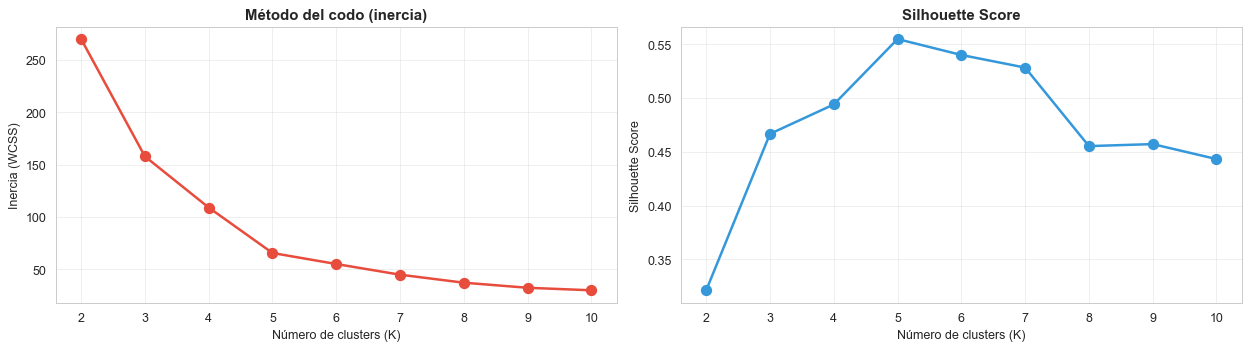


K con mejor silhouette: K = 5 (score = 0.5547)

→ Elegimos K = 5


In [27]:
def determinar_k_optimo(X, k_min=2, k_max=10):
    """
    Calcula la inercia y el silhouette score para diferentes valores de K
    y muestra los resultados gráficamente.
    """
    inertias = []
    silhouettes = []
    rango = range(k_min, k_max + 1)

    for k in rango:
        modelo = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        modelo.fit(X)
        inertias.append(modelo.inertia_)
        silhouettes.append(silhouette_score(X, modelo.labels_))

    # Graficar
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(rango, inertias, 'o-', color='#E74C3C', linewidth=2, markersize=8)
    axes[0].set_title('Método del codo (inercia)', fontweight='bold')
    axes[0].set_xlabel('Número de clusters (K)')
    axes[0].set_ylabel('Inercia (WCSS)')
    axes[0].grid(alpha=0.3)

    axes[1].plot(rango, silhouettes, 'o-', color='#3498DB', linewidth=2, markersize=8)
    axes[1].set_title('Silhouette Score', fontweight='bold')
    axes[1].set_xlabel('Número de clusters (K)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Imprimir resumen
    k_optimo = rango[np.argmax(silhouettes)]
    print(f"\nK con mejor silhouette: K = {k_optimo} (score = {max(silhouettes):.4f})")
    return k_optimo


K_OPTIMO = determinar_k_optimo(X_scaled)
print(f"\n→ Elegimos K = {K_OPTIMO}")

In [28]:
def entrenar_kmeans(X, k):
    """Entrena un modelo K-Means con la configuración recomendada."""
    modelo = KMeans(
        n_clusters=k,
        init='k-means++',   # Inicialización inteligente
        n_init=10,          # Corre 10 veces y elige el mejor
        max_iter=300,
        random_state=42
    )
    modelo.fit(X)
    return modelo


# Entrenar el modelo final con K=5
kmeans = entrenar_kmeans(X_scaled, K_OPTIMO)

# Guardar etiquetas en el dataframe original
df['Cluster'] = kmeans.labels_

print(f"Modelo entrenado con K = {K_OPTIMO}")
print(f"Iteraciones hasta converger: {kmeans.n_iter_}")
print(f"\nDistribución de clientes por cluster:")
print(df['Cluster'].value_counts().sort_index().to_string())

Modelo entrenado con K = 5
Iteraciones hasta converger: 4

Distribución de clientes por cluster:
Cluster
0    81
1    39
2    22
3    35
4    23


---
## 6. Evaluación del modelo

Para evaluar el clustering usamos:

| Métrica | Qué mide | Rango ideal |
|---|---|---|
| **Silhouette Score** | Qué tan bien separados están los clusters | Cercano a 1 |
| **Inercia (WCSS)** | Qué tan compactos son los clusters | Lo más bajo posible |
| **Visualización 2D** | Inspección visual de los clusters | Grupos claros |

MÉTRICAS DE EVALUACIÓN
  Silhouette Score: 0.5547
  Inercia (WCSS):   65.57

  ✓ Score > 0.5: estructura de clusters fuerte


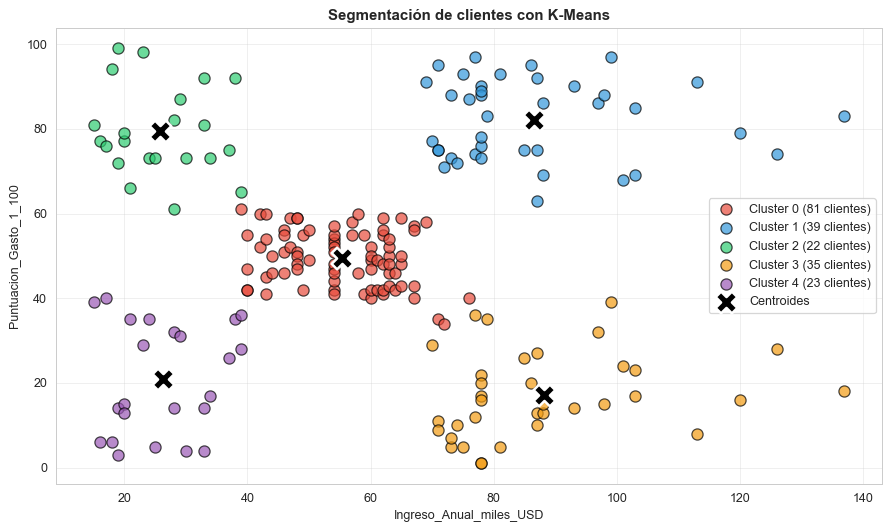

In [29]:
def evaluar_modelo(X, modelo):
    """Calcula y muestra las métricas principales del modelo."""
    sil = silhouette_score(X, modelo.labels_)
    inercia = modelo.inertia_
    print("MÉTRICAS DE EVALUACIÓN")
    print("="*40)
    print(f"  Silhouette Score: {sil:.4f}")
    print(f"  Inercia (WCSS):   {inercia:.2f}")
    if sil > 0.5:
        print(f"\n  ✓ Score > 0.5: estructura de clusters fuerte")
    elif sil > 0.25:
        print(f"\n  ~ Score entre 0.25 y 0.5: estructura razonable")
    else:
        print(f"\n  ✗ Score < 0.25: clusters poco definidos")
    return sil, inercia


def graficar_clusters_2d(df, X_scaled, modelo, scaler, columnas):
    """Visualiza los clusters en 2D con sus centroides en escala original."""
    centroides_orig = scaler.inverse_transform(modelo.cluster_centers_)
    colores = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

    plt.figure(figsize=(10, 6))
    for k in range(modelo.n_clusters):
        pts = df[df['Cluster'] == k]
        plt.scatter(pts[columnas[0]], pts[columnas[1]],
                    c=colores[k], s=80, alpha=0.7, edgecolor='black',
                    label=f'Cluster {k} ({len(pts)} clientes)')
    plt.scatter(centroides_orig[:, 0], centroides_orig[:, 1],
                c='black', marker='X', s=300, edgecolor='white',
                linewidth=2, label='Centroides')
    plt.title('Segmentación de clientes con K-Means', fontweight='bold')
    plt.xlabel(columnas[0])
    plt.ylabel(columnas[1])
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Evaluar y visualizar
sil_score, inercia = evaluar_modelo(X_scaled, kmeans)
graficar_clusters_2d(df, X_scaled, kmeans, scaler, COLS_CLUSTERING)

---
## 7. Ajuste de hiperparámetros

Comparamos diferentes configuraciones del algoritmo para confirmar que la nuestra (K-Means++ con `n_init=10`) es la mejor.

In [30]:
def comparar_configuraciones(X, k):
    """Prueba diferentes combinaciones de hiperparámetros y compara resultados."""
    configs = [
        {'init': 'random',      'n_init': 1,  'nombre': 'Random + n_init=1'},
        {'init': 'random',      'n_init': 10, 'nombre': 'Random + n_init=10'},
        {'init': 'k-means++',   'n_init': 1,  'nombre': 'K-Means++ + n_init=1'},
        {'init': 'k-means++',   'n_init': 10, 'nombre': 'K-Means++ + n_init=10 (recomendada)'},
    ]

    resultados = []
    for c in configs:
        m = KMeans(n_clusters=k, init=c['init'], n_init=c['n_init'],
                   max_iter=300, random_state=42)
        m.fit(X)
        resultados.append({
            'Configuración': c['nombre'],
            'Inercia': round(m.inertia_, 2),
            'Silhouette': round(silhouette_score(X, m.labels_), 4)
        })

    return pd.DataFrame(resultados)


resultados = comparar_configuraciones(X_scaled, K_OPTIMO)
print("COMPARACIÓN DE CONFIGURACIONES")
print(resultados.to_string(index=False))
print("\n→ K-Means++ con n_init=10 es la mejor combinación (más estable y mejor inercia)")

COMPARACIÓN DE CONFIGURACIONES
                      Configuración  Inercia  Silhouette
                  Random + n_init=1    98.81      0.4622
                 Random + n_init=10    65.57      0.5547
               K-Means++ + n_init=1    65.57      0.5547
K-Means++ + n_init=10 (recomendada)    65.57      0.5547

→ K-Means++ con n_init=10 es la mejor combinación (más estable y mejor inercia)


---
## 8. Interpretación de resultados

Cada cluster representa un perfil de cliente. Asignamos nombres descriptivos según los valores promedio de ingreso y gasto.

In [34]:
def perfilar_clusters(df, scaler, modelo, columnas):
    """Devuelve un dataframe con el perfil de cada cluster (centroides en escala original)."""
    centroides = scaler.inverse_transform(modelo.cluster_centers_)
    perfil = pd.DataFrame(centroides, columns=columnas)
    perfil['Clientes'] = df['Cluster'].value_counts().sort_index().values
    perfil['Porcentaje'] = (perfil['Clientes'] / len(df) * 100).round(1)
    perfil.index.name = 'Cluster'
    return perfil


def asignar_nombres_segmentos(perfil):
    """Asigna nombres descriptivos a cada cluster basándose en sus centroides."""
    nombres = []
    for _, row in perfil.iterrows():
        ingreso = row['Ingreso_Anual_miles_USD']
        gasto = row['Puntuacion_Gasto_1_100']
        if ingreso > 60 and gasto > 60:
            nombres.append('VIP / Premium')
        elif ingreso > 60 and gasto < 40:
            nombres.append('Cuidadosos')
        elif ingreso < 40 and gasto > 60:
            nombres.append('Impulsivos')
        elif ingreso < 40 and gasto < 40:
            nombres.append('Frugales')
        else:
            nombres.append('Estándar')
    return nombres


def formatear_perfil(perfil):
    """
    Convierte el perfil a una tabla legible:
    - Ingreso en dólares reales (con $ y comas)
    - Puntuación de gasto con 1 decimal
    - Porcentaje con símbolo %
    """
    tabla = pd.DataFrame()
    tabla['Segmento'] = perfil['Segmento']
    tabla['Ingreso Anual (USD)'] = perfil['Ingreso_Anual_miles_USD'].apply(
        lambda x: f"${x*1000:,.0f}"
    )
    tabla['Puntuación de Gasto'] = perfil['Puntuacion_Gasto_1_100'].apply(
        lambda x: f"{x:.1f} / 100"
    )
    tabla['Clientes'] = perfil['Clientes']
    tabla['Porcentaje'] = perfil['Porcentaje'].apply(lambda x: f"{x}%")
    return tabla


# Generar el perfil internamente
perfil = perfilar_clusters(df, scaler, kmeans, COLS_CLUSTERING)
perfil['Segmento'] = asignar_nombres_segmentos(perfil)

# Mostrar SOLO la tabla bonita
print("PERFIL DE CADA SEGMENTO DE CLIENTES")
print("=" * 70)
print(formatear_perfil(perfil).to_string())

PERFIL DE CADA SEGMENTO DE CLIENTES
              Segmento Ingreso Anual (USD) Puntuación de Gasto  Clientes Porcentaje
Cluster                                                                            
0             Estándar             $55,296          49.5 / 100        81      40.5%
1        VIP / Premium             $86,538          82.1 / 100        39      19.5%
2           Impulsivos             $25,727          79.4 / 100        22      11.0%
3           Cuidadosos             $88,200          17.1 / 100        35      17.5%
4             Frugales             $26,304          20.9 / 100        23      11.5%


---
## 9. Conclusiones

### ¿Qué tan bien funciona el modelo?

El modelo K-Means logró una segmentación muy efectiva de los 200 clientes en 5 grupos diferenciados:

| Métrica | Valor obtenido | Evaluación |
|---|---|---|
| Silhouette Score | **0.5547** | Estructura fuerte (>0.5) |
| Inercia (WCSS) | **65.57** | Clusters compactos |
| K óptimo | **5** | Confirmado por método del codo y silhouette |

### Segmentos descubiertos y estrategia de negocio

| Segmento | Ingreso (k$) | Gasto | % de clientes | Estrategia recomendada |
|---|---|---|---|---|
|  **VIP / Premium** | ~86 | Alto | 19.5% | Productos exclusivos, atención personalizada |
|  **Cuidadosos** | ~88 | Bajo | 17.5% | Reactivación, descuentos personalizados |
|  **Impulsivos** | ~26 | Alto | 11.0% | Promociones, financiación |
|  **Frugales** | ~26 | Bajo | 11.5% | Productos esenciales, ofertas agresivas |
|  **Estándar** | ~55 | Medio | 40.5% | Programas de fidelización general |

### Limitaciones

- K debe especificarse manualmente (lo resolvimos con método del codo).
- Sensible a outliers (en este dataset no fue problema).
- Asume clusters esféricos (DBSCAN o GMM serían mejores para formas irregulares).
- Resultados dependen de la inicialización (mitigado con `n_init=10`).
- Solo se usaron 2 features para el modelo final (ingreso y gasto).

### Posibles mejoras

- Incluir más variables: historial de compras, frecuencia de visitas, ticket promedio.
- Probar **DBSCAN** o **GMM** para comparar resultados.
- Aplicar **PCA** si se agregan más variables (reducción de dimensionalidad).
- Validar la estabilidad de los clusters con datos de distintos meses.

---
## Referencias

[1] V. J. Choudhary, "Mall Customer Segmentation Data," *Kaggle*, 2018. [Online]. Available: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

[2] J. MacQueen, "Some methods for classification and analysis of multivariate observations," in *Proc. 5th Berkeley Symp. Math. Statist. Prob.*, vol. 1, 1967, pp. 281–297.

[3] D. Arthur and S. Vassilvitskii, "k-means++: The advantages of careful seeding," in *Proc. 18th Annual ACM-SIAM Symposium on Discrete Algorithms*, 2007, pp. 1027–1035.

[4] P. J. Rousseeuw, "Silhouettes: a graphical aid to the interpretation and validation of cluster analysis," *J. Computational and Applied Mathematics*, vol. 20, pp. 53–65, 1987.

[5] Scikit-learn Developers, "sklearn.cluster.KMeans," *Scikit-learn Documentation*, 2024. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html